# NSGA-III budget-front analysis

Analysis of a `cmc.moo` run with the **budget genome**: every network was trained to do the core5 tasks
as well as it could while staying under a metabolic ceiling (rate budget, enforced by a learned multiplier)
and a wiring ceiling (projection of `W_rec` onto the L1 ball after every step). NSGA-III chose which
budgets to try. There are no hand-set lambdas anywhere.

**Part 1** repeats the `lambda_pareto_analysis.ipynb` views, so the two methods can be read side by side.
**Part 2** is what only this kind of run can show:

| § | Question | Why the lambda grid could not answer it |
|---|---|---|
| 2.1 | Are there front points *no* weighted sum can reach? | the grid *is* a weighted sum |
| 2.2 | How much firing buys how much wiring, at fixed competence? | 36 points cannot resolve iso-accuracy curves |
| 2.3 | What is metabolism *worth* at each budget (shadow price)? | on the grid lambda is an input, here an output |
| 2.4 | Where exactly do networks stop doing all tasks? | the grid put 60% of its points past that edge or in one corner |
| 2.5 | Which task breaks first under each cost? | needs dense sampling near the edge |
| 2.6 | Did the search converge, and how much more front does it cover? | hypervolume per network trained |
| 2.7 | Which budgets to zoom into for motif analysis? | knee detection on a dense front |

Every network is **one training seed** (seed 0). Wherever a conclusion could be a lucky seed, the notebook
says so and uses an estimate of the seed noise.

## Setup
`RUN_DIR`: the budget run. `REF_DIR`: the core5 6x6 lambda grid it is compared against. `LAMBDA_RUN`: the
NSGA-III run over lambdas (genome A), kept for the convergence comparison in 2.6. Feasible = `min_task_acc
>= 0.6`, the same rule as the Pareto front everywhere else in the repo.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.spatial import cKDTree

from cmc.front import FEASIBLE_MIN_TASK_ACC, compute_front, pareto_mask
from cmc.paths import LAMBDA_PARETO_RUNS_DIR, MOO_RUNS_DIR

RUN_DIR = MOO_RUNS_DIR / "dale_core5_nsga3_budget_p24g10"
REF_DIR = LAMBDA_PARETO_RUNS_DIR / "dale_core5_6x6_2026_09_23_05_45_12_5802320"
LAMBDA_RUN = MOO_RUNS_DIR / "dale_core5_nsga3_lambda_p8g4_2026_09_24_23_11_03"

TASKS = ["fdgo", "fdanti", "dm1", "contextdm1", "dmsgo"]
OBJ = ("min_task_acc", "metabolic_cost", "wiring_cost")

df = pd.read_csv(RUN_DIR / "runs.csv")
df["is_feasible"] = df["min_task_acc"] >= FEASIBLE_MIN_TASK_ACC
df["is_pareto"], _ = compute_front(df.to_dict("records"), OBJ)
feas = df[df.is_feasible]
front = df[df.is_pareto]

ref = pd.read_csv(REF_DIR / "runs.csv")
ref["is_feasible"] = ref["min_task_acc"] >= FEASIBLE_MIN_TASK_ACC
ref0 = ref[(ref.seed == 0) & ref.is_feasible].copy()          # same training seed as the moo run
ref0["is_pareto"], _ = compute_front(ref0.to_dict("records"), OBJ)
lam = pd.read_csv(LAMBDA_RUN / "runs.csv")
lam["is_feasible"] = lam["min_task_acc"] >= FEASIBLE_MIN_TASK_ACC

summary = json.loads((RUN_DIR / "summary.json").read_text())
print(f"{len(df)} networks, {len(feas)} feasible, {len(front)} on the front")
print(f"reference grid (seed 0): {len(ref0)} feasible, {int(ref0.is_pareto.sum())} on its front")
print("reference check:", summary.get("reference_check"))

240 networks, 204 feasible, 124 on the front
reference grid (seed 0): 14 feasible, 11 on its front
reference check: {'reference_run': 'pareto_runs/dale_core5_6x6_2026_09_23_05_45_12_5802320', 'n_found_feasible': 204, 'n_reference_feasible_seed0': 14, 'n_found_dominated_by_reference_seed0': 3}


### Seed-noise estimate
We only have one seed per network, but neighbouring budgets should give similar networks. So the noise is
estimated from how much each network differs from its 5 nearest neighbours in (log rate budget, log wiring
budget). This slightly *over*estimates noise (real variation between neighbours counts as noise), which makes
every "this is significant" statement below conservative.

In [2]:
def knn_noise(frame, col, k=5):
    X = np.c_[np.log10(frame.rate_budget), np.log10(frame.conn_budget)]
    _, idx = cKDTree(X).query(X, k=k + 1)
    y = frame[col].to_numpy()
    resid = y - y[idx[:, 1:]].mean(axis=1)
    return float(resid.std() * np.sqrt(k / (k + 1)))

SIGMA_ACC = knn_noise(feas, "min_task_acc")
SIGMA_LOSS = knn_noise(feas, "task_loss")
print(f"seed noise: min_task_acc ~ {SIGMA_ACC:.3f}, task_loss ~ {SIGMA_LOSS:.2e}")

seed noise: min_task_acc ~ 0.022, task_loss ~ 1.85e-04


# Part 1 — the same views as `lambda_pareto_analysis.ipynb`

## 1.1 Front projections
Grey dots: networks that do all tasks but are dominated. Crosses: networks that fail a task (excluded from
the front). Coloured: the moo front. Black rings: the grid's seed-0 front. A point is on the front if no
other network is at least as good on all three of (worst-task accuracy, metabolic cost, wiring cost) and
strictly better on one.

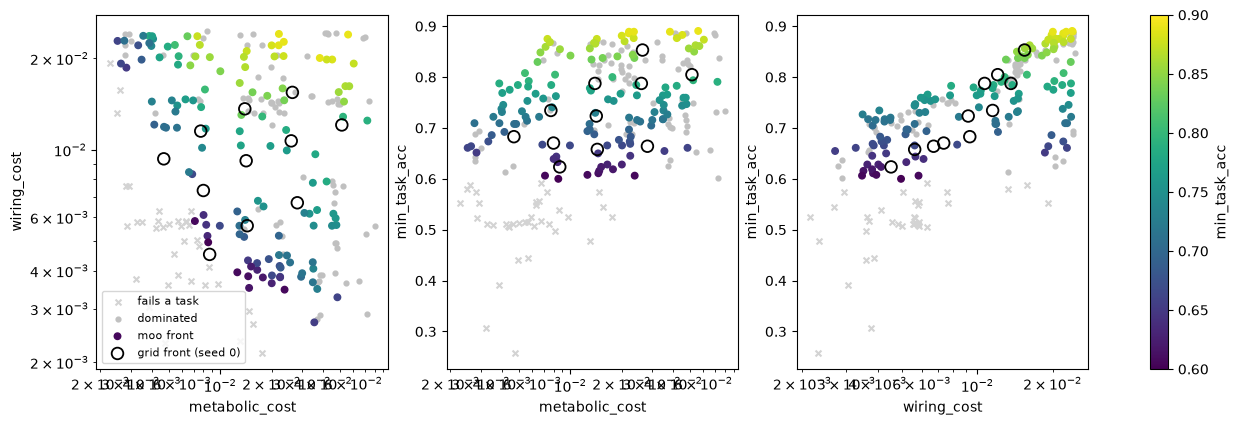

In [3]:
pairs = [("metabolic_cost", "wiring_cost"), ("metabolic_cost", "min_task_acc"), ("wiring_cost", "min_task_acc")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (x, y) in zip(axes, pairs):
    bad = df[~df.is_feasible]
    ax.scatter(bad[x], bad[y], marker="x", s=18, c="lightgrey", label="fails a task")
    dom = feas[~feas.is_pareto]
    ax.scatter(dom[x], dom[y], s=12, c="silver", label="dominated")
    sc = ax.scatter(front[x], front[y], s=22, c=front.min_task_acc, cmap="viridis", vmin=0.6, vmax=0.9, label="moo front")
    rf = ref0[ref0.is_pareto & (ref0.lambda_rate > 0)]
    ax.scatter(rf[x], rf[y], s=70, facecolors="none", edgecolors="k", lw=1.3, label="grid front (seed 0)")
    ax.set_xscale("log")
    if y != "min_task_acc":
        ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(y)
fig.colorbar(sc, ax=axes, label="min_task_acc")
axes[0].legend(fontsize=8, loc="lower left")
plt.show()

## 1.2 The front in 3D (interactive)

The same networks in all three objectives at once, as in `lambda_pareto_analysis.ipynb`: drag to rotate, scroll to
zoom, hover a point for its budgets, learned price and per-task accuracy, click legend entries to hide a
group. Costs are on log10 axes. The translucent orange plane is the acceptable accuracy
(min_task_acc = 0.6): everything below it fails at least one task. Front points are coloured by worst-task accuracy; black diamonds are the
grid's seed-0 front for comparison.

In [4]:
import plotly.graph_objects as go

def hover(sub, kind):
    if kind == "grid":
        head = [f"grid  λ_rate={r.lambda_rate:.3g}  λ_conn={r.lambda_connectivity:.3g}" for r in sub.itertuples()]
    else:
        head = [f"budget rate={r.rate_budget:.4g}  conn={r.conn_budget:.4g}<br>"
                f"learned λ_rate={r.final_lambda_rate:.3g}  (gen {int(r.generation)})" for r in sub.itertuples()]
    return [
        f"{h}<br>min_task_acc={r.min_task_acc:.3f}  mean={r.mean_acc:.3f}  dmsgo={r.acc_dmsgo:.3f}<br>"
        f"metabolic={r.metabolic_cost:.4f}  wiring={r.wiring_cost:.4f}  conn_frac={r.conn_frac:.3f}"
        for h, r in zip(head, sub.itertuples())
    ]

def xyz(sub):
    return dict(x=np.log10(sub.metabolic_cost), y=np.log10(sub.wiring_cost), z=sub.min_task_acc)

bad, dom = df[~df.is_feasible], feas[~feas.is_pareto]
grid_front = ref0[ref0.is_pareto & (ref0.lambda_rate > 0)]
fig = go.Figure([
    go.Scatter3d(**xyz(bad), mode="markers", name=f"fails a task ({len(bad)})",
                 marker=dict(size=3, color="lightgrey", symbol="x"), hovertext=hover(bad, "moo"), hoverinfo="text"),
    go.Scatter3d(**xyz(dom), mode="markers", name=f"dominated ({len(dom)})",
                 marker=dict(size=3, color="silver", opacity=0.6), hovertext=hover(dom, "moo"), hoverinfo="text"),
    go.Scatter3d(**xyz(front), mode="markers", name=f"moo front ({len(front)})",
                 marker=dict(size=5, color=front.min_task_acc, colorscale="Viridis", cmin=0.6, cmax=0.9,
                             colorbar=dict(title="min_task_acc", x=1.0)),
                 hovertext=hover(front, "moo"), hoverinfo="text"),
    go.Scatter3d(**xyz(grid_front), mode="markers", name=f"grid front, seed 0 ({len(grid_front)})",
                 marker=dict(size=7, color="black", symbol="diamond"), hovertext=hover(grid_front, "grid"), hoverinfo="text"),
])
# Acceptable-accuracy plane: networks below it fail at least one task.
X_, Y_ = np.log10(df.metabolic_cost), np.log10(df.wiring_cost)
pad = lambda v: (v.min() - 0.05 * (v.max() - v.min()), v.max() + 0.05 * (v.max() - v.min()))
(x0, x1), (y0, y1) = pad(X_), pad(Y_)
fig.add_trace(go.Surface(
    x=[x0, x1], y=[y0, y1], z=[[FEASIBLE_MIN_TASK_ACC] * 2] * 2,
    colorscale=[[0, "orange"], [1, "orange"]], opacity=0.2, showscale=False,
    name=f"acceptable: min_task_acc = {FEASIBLE_MIN_TASK_ACC}", showlegend=True, hoverinfo="skip",
))
fig.update_layout(
    title=f"Budget front (3D) — core5, {len(df)} networks",
    scene=dict(xaxis_title="log10(metabolic cost)", yaxis_title="log10(wiring cost)",
               zaxis_title="min_task_acc", aspectmode="cube"),
    width=950, height=720, legend=dict(x=0.0, y=1.0),
)
fig.show()

## 1.3 Front table
Sorted by worst-task accuracy. `final_lambda_rate` is the weight the rate budget settled on during
training (compare with the grid's `lambda_rate` inputs).

In [5]:
cols = ["generation", "rate_budget", "conn_budget", "final_lambda_rate", "min_task_acc", "mean_acc",
        "metabolic_cost", "wiring_cost", "conn_frac"] + [f"acc_{t}" for t in TASKS]
front[cols].sort_values("min_task_acc", ascending=False).round(4).head(25)

,generation,rate_budget,conn_budget,final_lambda_rate,min_task_acc,mean_acc,metabolic_cost,wiring_cost,conn_frac,acc_fdgo,acc_fdanti,acc_dm1,acc_contextdm1,acc_dmsgo
177,7,0.0538,0.0239,0.0005,0.8906,0.9781,0.0559,0.0239,0.7210,1.0,1.0,1.0,1.0000,0.8906
96,4,0.0202,0.0241,0.0128,0.8891,0.9778,0.0221,0.0241,0.7097,1.0,1.0,1.0,1.0000,0.8891
133,5,0.0214,0.0227,0.0110,0.8891,0.9775,0.0236,0.0227,0.6745,1.0,1.0,1.0,0.9984,0.8891
118,4,0.0354,0.0200,0.0027,0.8891,0.9778,0.0382,0.0200,0.6102,1.0,1.0,1.0,1.0000,0.8891
55,2,0.0200,0.0221,0.0137,0.8859,0.9769,0.0220,0.0221,0.6566,1.0,1.0,1.0,0.9984,0.8859
54,2,0.0425,0.0198,0.0014,0.8828,0.9766,0.0452,0.0198,0.6043,1.0,1.0,1.0,1.0000,0.8828
44,1,0.0181,0.0221,0.0182,0.8812,0.9759,0.0200,0.0221,0.6556,1.0,1.0,1.0,0.9984,0.8812
89,3,0.0392,0.0198,0.0018,0.8766,0.9753,0.0420,0.0198,0.6040,1.0,1.0,1.0,1.0000,0.8766
111,4,0.0214,0.0203,0.0121,0.8766,0.9753,0.0235,0.0203,0.6111,1.0,1.0,1.0,1.0000,0.8766
184,7,0.0070,0.0236,0.1218,0.8750,0.9744,0.0074,0.0236,0.6936,1.0,1.0,1.0,0.9969,0.8750


## 1.4 Were the budgets respected?
The wiring budget is enforced by projection, so wiring cost should sit exactly on the budget. The rate
budget is enforced during training; eval uses different trials (per task, no training batch mix), so the
measured metabolic cost is expected to differ by a roughly constant factor. What matters is that the
factor is *constant* — then the budget axis is just rescaled, not distorted.

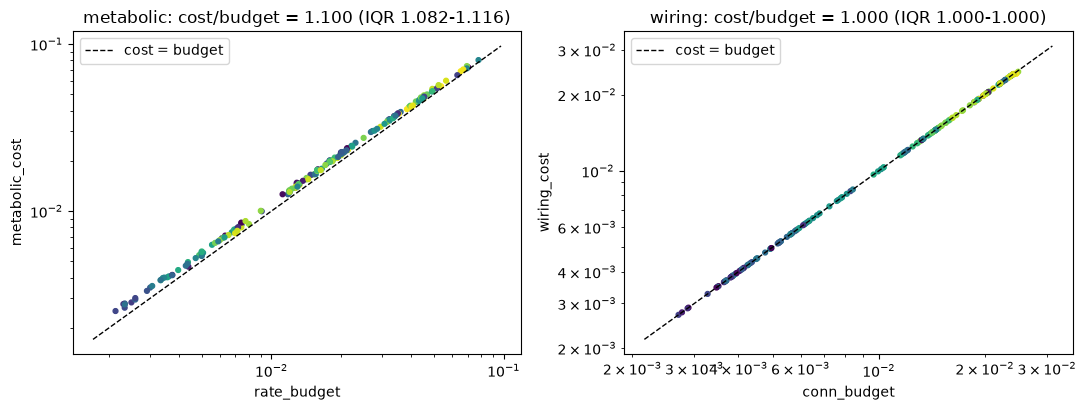

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (b, c, name) in zip(axes, [("rate_budget", "metabolic_cost", "metabolic"), ("conn_budget", "wiring_cost", "wiring")]):
    ratio = feas[c] / feas[b]
    ax.scatter(feas[b], feas[c], s=12, c=feas.min_task_acc, cmap="viridis")
    lims = [feas[b].min() * 0.8, feas[b].max() * 1.25]
    ax.plot(lims, lims, "k--", lw=1, label="cost = budget")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(b); ax.set_ylabel(c)
    ax.set_title(f"{name}: cost/budget = {ratio.median():.3f} (IQR {ratio.quantile(.25):.3f}-{ratio.quantile(.75):.3f})")
    ax.legend()
plt.tight_layout(); plt.show()

> **What we see (Part 1).** 204 of 240 networks do every task; only 3 of them are dominated by a grid
> network, and the front reaches further on every axis: metabolic cost down to 0.0025 (grid: 0.0047),
> wiring down to 0.0027 (grid: 0.0045), worst-task accuracy up to 0.89 (grid: 0.85). Wiring lands exactly
> on its budget. Metabolic cost is 1.10x the rate budget with +-3% spread -- a constant factor, so the
> budget axis is rescaled, not distorted. The "124 on the front" is inflated by seed noise (one seed per
> network lets noise make points look non-dominated); read the front as a band, not a line.

# Part 2 — what only the budget search can show

## 2.1 Non-convexity: front points no weighted sum can reach

**The idea.** Weighted-sum training (the lambda grid) minimises `task_loss + λ_rate·metabolic + λ_conn·wiring`.
Picture all networks as points in (task_loss, metabolic, wiring) space. A fixed (λ_rate, λ_conn) is a tilted
plane, and training slides that plane in until it touches the cloud: the touching point is what the weighted
sum finds. Whatever the tilt, the plane can only ever touch the **convex hull** of the cloud. A front
point sitting in a *dent* of the front — between hull points — is never touched by any plane, so **no
choice of lambdas, however fine the grid, finds it.** Such points are called *unsupported*.

**The test.** This space is where the weighted sum actually acts, so we use `task_loss` (what training
minimises), not accuracy. For each network on the (task_loss, metabolic, wiring) front we solve a small linear
program: find λ ≥ 0 that makes this network the weighted-sum winner against all 240 networks, allowing the
smallest possible slack `s`. If `s = 0` some lambda picks it (supported). If `s > 0`, the network loses to
some other network under *every* lambda by at least `s` in task loss: it sits in a dent of depth `s`.

**Noise.** A single noisy seed can fake a shallow dent, so a dent only counts if `s > 2 σ_loss`.

In [7]:
C = df[["task_loss", "metabolic_cost", "wiring_cost"]].to_numpy()
loss_front = pareto_mask(C, maximize=[False, False, False])

def support_gap(i):
    p = C[i]
    others = np.delete(C, i, axis=0)
    # variables (lam_rate, lam_conn, s): minimise s subject to, for every other network q,
    # (loss_p - loss_q) + lam_rate (m_p - m_q) + lam_conn (w_p - w_q) <= s
    A = np.c_[p[1] - others[:, 1], p[2] - others[:, 2], -np.ones(len(others))]
    b = others[:, 0] - p[0]
    res = linprog([0, 0, 1], A_ub=A, b_ub=b, bounds=[(0, None), (0, None), (0, None)], method="highs")
    # s is floored at 0: extreme points can win by any margin as lambda grows, and
    # only "s = 0 (some lambda picks it) or not" matters.
    return res.x[2], res.x[0], res.x[1]

rows = []
for i in np.flatnonzero(loss_front):
    s, lr, lc = support_gap(i)
    rows.append({"idx": i, "gap": s, "lambda_rate": lr, "lambda_conn": lc})
sup = pd.DataFrame(rows).set_index("idx").join(df)
sup["unsupported"] = sup.gap > 2 * SIGMA_LOSS
print(f"(task_loss, metabolic, wiring) front: {len(sup)} networks")
print(f"  supported (a weighted sum can find them): {(sup.gap <= 1e-12).sum()}")
print(f"  in a dent, but shallower than 2 sigma noise: {((sup.gap > 1e-12) & ~sup.unsupported).sum()}")
print(f"  unsupported beyond noise (no lambda can find them): {sup.unsupported.sum()}")
sup.loc[sup.unsupported, ["gap", "rate_budget", "conn_budget", "min_task_acc", "task_loss",
                          "metabolic_cost", "wiring_cost", "is_feasible"]].sort_values("gap", ascending=False).round(5)

(task_loss, metabolic, wiring) front: 174 networks
  supported (a weighted sum can find them): 62
  in a dent, but shallower than 2 sigma noise: 99
  unsupported beyond noise (no lambda can find them): 13


,gap,rate_budget,conn_budget,min_task_acc,task_loss,metabolic_cost,wiring_cost,is_feasible
idx,,,,,,,,
36,0.00300,0.00275,0.00579,0.50938,0.01701,0.00352,0.00579,False
198,0.00245,0.00380,0.00360,0.44062,0.01771,0.00498,0.00360,False
9,0.00240,0.00424,0.00388,0.44375,0.01396,0.00569,0.00388,False
8,0.00197,0.00328,0.00554,0.51094,0.01395,0.00422,0.00554,False
229,0.00171,0.00338,0.00583,0.50781,0.01236,0.00432,0.00583,False
168,0.00154,0.00365,0.00558,0.51094,0.01166,0.00466,0.00558,False
148,0.00094,0.00639,0.00481,0.51094,0.00749,0.00752,0.00481,False
61,0.00070,0.00632,0.00503,0.57500,0.00725,0.00730,0.00503,False
217,0.00064,0.00742,0.00496,0.60000,0.00677,0.00853,0.00496,True


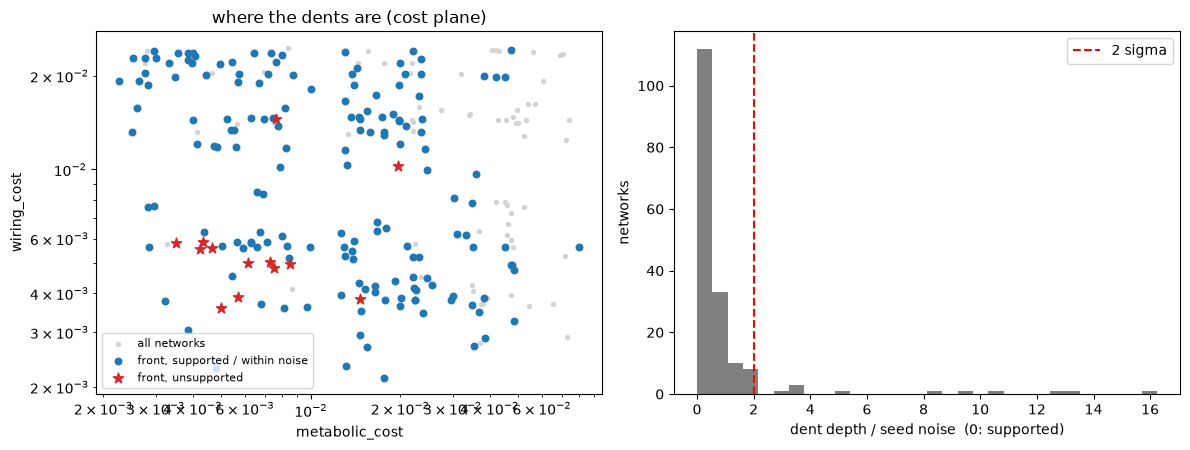

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
ax.scatter(df.metabolic_cost, df.wiring_cost, s=8, c="lightgrey", label="all networks")
s_ = sup[~sup.unsupported]
ax.scatter(s_.metabolic_cost, s_.wiring_cost, s=22, c="tab:blue", label="front, supported / within noise")
u_ = sup[sup.unsupported]
ax.scatter(u_.metabolic_cost, u_.wiring_cost, s=60, c="tab:red", marker="*", label="front, unsupported")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("metabolic_cost"); ax.set_ylabel("wiring_cost")
ax.legend(fontsize=8); ax.set_title("where the dents are (cost plane)")
ax = axes[1]
ax.hist(sup.gap / SIGMA_LOSS, bins=30, color="grey")
ax.axvline(2, color="r", ls="--", label="2 sigma")
ax.set_xlabel("dent depth / seed noise  (0: supported)"); ax.set_ylabel("networks"); ax.legend()
plt.tight_layout(); plt.show()

> **What we see (2.1).** Of the 174 networks on the (task_loss, metabolic, wiring) front, 62 are supported
> (some lambda finds them), 99 sit in dents shallower than the seed noise, and **13 are unsupported beyond
> noise**. But look at *where*: 9 of the 13 fail a task -- they sit on the **feasibility cliff**, where
> task loss jumps as the budgets tighten. A cliff is itself a non-convexity: a tilted plane either stays
> above it or falls off it, so no weighted sum lands on its slope. The remaining 4 are feasible networks
> in dents of 2-3 sigma: suggestive, not conclusive at one seed.
>
> So the front is **mostly convex where networks work well**, and **non-convex at the edge of doing the
> tasks**. That edge is exactly where the grid lost its points (60% of the 5x5 was past it), and it is
> where the most constrained -- for the motif question, the most interesting -- networks live.

## 2.2 Iso-accuracy cost curves: how much firing buys how much wiring

For a target competence (say, every task at least 75% correct), take all networks that reach it and keep
the cheapest cost combinations: the non-dominated set in the (metabolic, wiring) plane. Connected, that is
the **iso-accuracy curve**: the frontier of what it costs to be that competent. Its slope is the exchange
rate between the two costs — how many units of firing a network must spend to save one unit of wiring
while staying equally good. A curve hugging the axes means the costs are interchangeable at no loss;
an L-shaped curve means each cost has a floor the other cannot compensate.

Raising the target shifts the curve outward: competence costs resources.

acc >= 0.65: cheapest metabolic 0.0025 (needs wiring 0.0228); cheapest wiring 0.0027 (needs metabolic 0.0355)
acc >= 0.75: cheapest metabolic 0.0039 (needs wiring 0.0237); cheapest wiring 0.0060 (needs metabolic 0.0473)
acc >= 0.85: cheapest metabolic 0.0072 (needs wiring 0.0203); cheapest wiring 0.0144 (needs metabolic 0.0530)


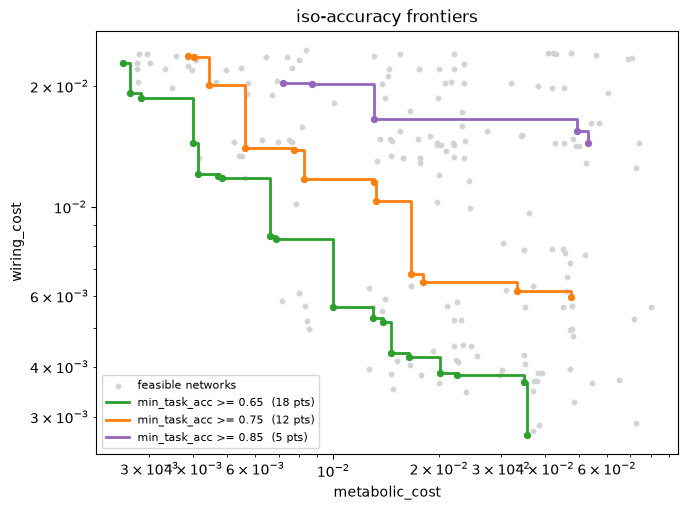

In [9]:
def cost_frontier(frame):
    pts = frame[["metabolic_cost", "wiring_cost"]].to_numpy()
    keep = pareto_mask(pts, maximize=[False, False])
    return frame[keep].sort_values("metabolic_cost")

LEVELS = [0.65, 0.75, 0.85]
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(feas.metabolic_cost, feas.wiring_cost, s=10, c="lightgrey", label="feasible networks")
for level, color in zip(LEVELS, ["tab:green", "tab:orange", "tab:purple"]):
    fr = cost_frontier(feas[feas.min_task_acc >= level])
    ax.step(fr.metabolic_cost, fr.wiring_cost, where="post", color=color, lw=2, label=f"min_task_acc >= {level}  ({len(fr)} pts)")
    ax.scatter(fr.metabolic_cost, fr.wiring_cost, color=color, s=18)
    print(f"acc >= {level}: cheapest metabolic {fr.metabolic_cost.min():.4f} (needs wiring {fr.iloc[0].wiring_cost:.4f}); "
          f"cheapest wiring {fr.wiring_cost.min():.4f} (needs metabolic {fr.iloc[-1].metabolic_cost:.4f})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("metabolic_cost"); ax.set_ylabel("wiring_cost")
ax.set_title("iso-accuracy frontiers"); ax.legend(fontsize=8)
plt.show()

> **What we see (2.2).** The costs trade off, and the exchange rate depends on competence:
>
> | competence | cheapest firing (needs wiring) | cheapest wiring (needs firing) |
> |---|---|---|
> | acc >= 0.65 | 0.0025 (0.0228) | 0.0027 (0.0355) |
> | acc >= 0.75 | 0.0039 (0.0237) | 0.0060 (0.0473) |
> | acc >= 0.85 | 0.0072 (0.0203) | 0.0144 (0.0530) |
>
> At 0.65 the curve spans a decade on both axes: **sparse wiring can be bought with ~14x more firing**, and
> vice versa. At 0.85 it turns into an L: wiring cannot drop below ~0.014 whatever the firing, i.e. **high
> competence needs dense connectivity; firing can no longer substitute for it**. This is the quantitative
> version of "sparse circuits need higher rates", and it is what the motif analysis should explain.

## 2.3 Shadow prices: what is metabolism worth?

In constrained optimisation the multiplier of a constraint has a meaning: it is the **shadow price** of
the budget — how much task loss one extra unit of metabolic budget would save at the optimum. The
rate-budget multiplier learned during training (`final_lambda_rate`) is exactly that. A high price means
the network is starved of firing and every bit more helps; a price near zero means the budget no longer
binds.

On the lambda grid, lambda was an *input* we chose. Here it is an *output* the network settled on. That
gives a consistency check: if both methods find the same optimal networks, a grid network trained at
`lambda_rate` = λ should have the same metabolic cost as a budget network whose price came out at λ.
Grid points (black rings) should therefore fall on the same curve as the budget networks.

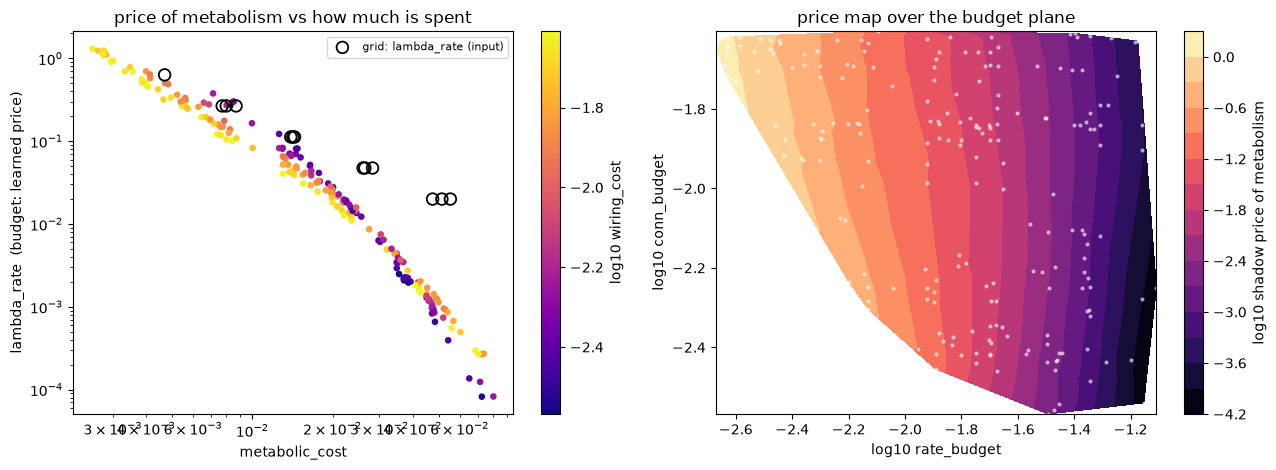

price ~ metabolic^-2.57 over the budget networks (the grid measured metabolic ~ lambda^-0.674, i.e. lambda ~ metabolic^-1.48)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
sc = ax.scatter(feas.metabolic_cost, feas.final_lambda_rate, s=14, c=np.log10(feas.wiring_cost), cmap="plasma")
g = ref0[ref0.lambda_rate > 0]
ax.scatter(g.metabolic_cost, g.lambda_rate, s=70, facecolors="none", edgecolors="k", lw=1.3, label="grid: lambda_rate (input)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("metabolic_cost"); ax.set_ylabel("lambda_rate  (budget: learned price)")
ax.legend(fontsize=8); fig.colorbar(sc, ax=ax, label="log10 wiring_cost")
ax.set_title("price of metabolism vs how much is spent")
ax = axes[1]
tc = ax.tricontourf(np.log10(feas.rate_budget), np.log10(feas.conn_budget), np.log10(feas.final_lambda_rate), levels=14, cmap="magma")
ax.scatter(np.log10(feas.rate_budget), np.log10(feas.conn_budget), s=4, c="w", alpha=.5)
fig.colorbar(tc, ax=ax, label="log10 shadow price of metabolism")
ax.set_xlabel("log10 rate_budget"); ax.set_ylabel("log10 conn_budget"); ax.set_title("price map over the budget plane")
plt.tight_layout(); plt.show()
slope = np.polyfit(np.log10(feas.metabolic_cost), np.log10(feas.final_lambda_rate), 1)[0]
print(f"price ~ metabolic^{slope:.2f} over the budget networks "
      f"(the grid measured metabolic ~ lambda^-0.674, i.e. lambda ~ metabolic^{-1/0.674:.2f})")

> **What we see (2.3).** Two things.
>
> 1. **The price of metabolism depends on the rate budget alone** (right: contours are vertical; left:
>    colour, i.e. wiring, does not shift the cloud). How sparse a network is does not change what firing is worth.
> 2. **The duality check holds only where the rate budget binds hard.** For prices of ~0.1-1 (metabolic
>    below ~0.01) the grid's lambdas fall on the budget cloud to within ~1.5x. At loose budgets the learned
>    price drops far below the grid lambda at the same metabolic cost (at 0.055: grid 0.02, learned ~0.0005).
>    The learned multiplier is its value where training *ended*, while the grid lambda acted over the whole
>    run, and late in training a network needs very little pressure to hold its rate. So read the price as
>    an **ordinal** "how tight is this budget", reliable in the binding regime, not as an exact marginal
>    value everywhere.

## 2.4 Feasibility map: where networks stop doing all tasks

Worst-task accuracy over the plane of the two budgets, interpolated between the 240 networks. The bold line
is the 0.6 contour — the edge of "does every task". Crosses are networks that failed a task. Because NSGA-III
kept pushing costs down, sampling is densest right at this edge, which is where it matters.

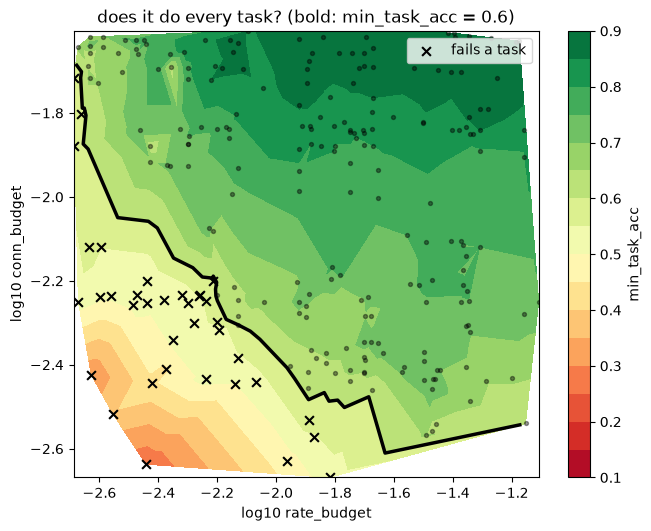

In [11]:
x, y = np.log10(df.rate_budget), np.log10(df.conn_budget)
fig, ax = plt.subplots(figsize=(7.5, 5.8))
tc = ax.tricontourf(x, y, df.min_task_acc, levels=np.linspace(0.1, 0.9, 17), cmap="RdYlGn")
ax.tricontour(x, y, df.min_task_acc, levels=[FEASIBLE_MIN_TASK_ACC], colors="k", linewidths=2.5)
ok = df.is_feasible
ax.scatter(x[ok], y[ok], s=8, c="k", alpha=.4)
ax.scatter(x[~ok], y[~ok], s=40, marker="x", c="k", label="fails a task")
fig.colorbar(tc, ax=ax, label="min_task_acc")
ax.set_xlabel("log10 rate_budget"); ax.set_ylabel("log10 conn_budget"); ax.legend(loc="upper right")
ax.set_title("does it do every task? (bold: min_task_acc = 0.6)")
plt.show()

> **What we see (2.4).** The edge (bold line) runs diagonally: along it, halving one budget has to be paid
> for by roughly doubling the other (slope ~ -0.85 in log-log, i.e. rate^0.85 x wiring ~ constant). Neither
> budget alone decides whether a network can do the tasks; to first order their *product* does. All
> infeasible networks sit in the low-low corner, and NSGA-III sampled the edge densely, as intended.

## 2.5 Which task breaks first?

`min_task_acc` is the accuracy of whichever task is worst. Do the costs hurt the tasks evenly, or one
computation first? The table shows each task's accuracy over all feasible networks; the plot shows each
task along the wiring and metabolic axes (binned means).

worst task per feasible network: {'dmsgo': 204}


,acc_fdgo,acc_fdanti,acc_dm1,acc_contextdm1,acc_dmsgo
mean,1.0,0.999,1.000,0.999,0.759
std,0.0,0.004,0.001,0.002,0.081
min,1.0,0.953,0.989,0.989,0.600
max,1.0,1.000,1.000,1.000,0.891


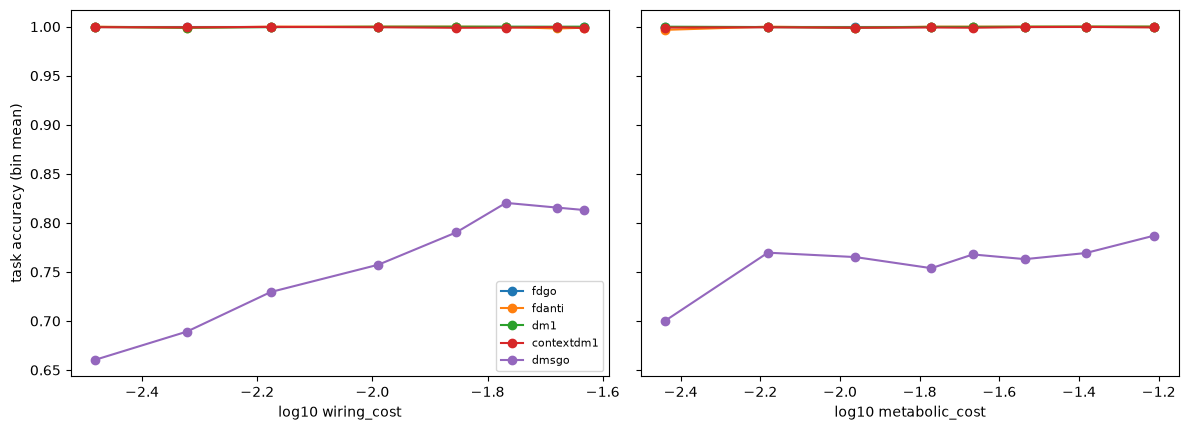

In [12]:
acc_cols = [f"acc_{t}" for t in TASKS]
bottleneck = feas[acc_cols].idxmin(axis=1).str.replace("acc_", "")
print("worst task per feasible network:", bottleneck.value_counts().to_dict())
display(feas[acc_cols].describe().loc[["mean", "std", "min", "max"]].round(3))
colors = dict(zip(TASKS, plt.cm.tab10.colors))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, c in zip(axes, ["wiring_cost", "metabolic_cost"]):
    bins = pd.qcut(np.log10(feas[c]), 8)
    means = feas.groupby(bins, observed=True)[acc_cols].mean()
    mid = [iv.mid for iv in means.index]
    for t in TASKS:
        ax.plot(mid, means[f"acc_{t}"], "o-", color=colors[t], label=t)
    ax.set_xlabel(f"log10 {c}")
axes[0].set_ylabel("task accuracy (bin mean)"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

> **What we see (2.5).** **dmsgo is the worst task in all 204 feasible networks** (and in all 51 feasible
> grid networks). The other four tasks stay at 95-100% across the whole budget plane; dmsgo averages 0.76,
> 24 points below the next-worst task. So on core5, `min_task_acc` *is* dmsgo accuracy, and every front in
> this notebook is really "delayed match-to-sample vs the two costs".
>
> dmsgo is the only core5 task that must **hold a stimulus in memory across a delay** and compare it with
> a second one; the others are perceptual decisions answered while or right after the stimulus is on.
> Holding a memory needs sustained recurrent activity -- which costs firing, carried by recurrent loops,
> which cost wiring -- so it is plausible that the budgets bite on memory first. Two consequences: the
> motif analysis should look for **what supports persistent activity** at the chosen budgets, and a
> battery with more memory tasks would change the front, not just its scale.

## 2.6 Convergence and coverage: hypervolume

**Hypervolume** turns a whole front into one number: the volume of objective space it dominates, measured
from a fixed reference point (the "worst acceptable" corner). Bigger = the front reaches further toward
cheap-and-accurate. Objectives are (1 − min_task_acc, log10 metabolic, log10 wiring), normalised to [0, 1] over
all three runs so the axes weigh equally; only feasible networks count.

Plotted against **networks trained**, it shows both convergence (does the curve flatten?) and efficiency
(how much front per unit compute) for the budget search, the lambda search (genome A) and the grid.
The grid's lambda=0 anchor (metabolic 0.57) lies outside the reference box and contributes nothing.

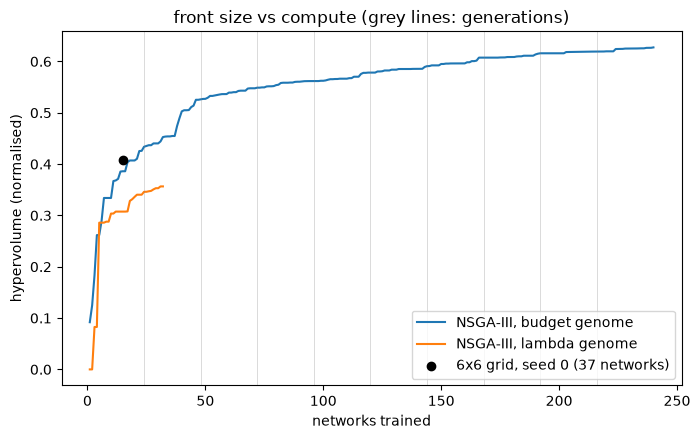

hypervolume: budget 0.627, lambda-genome 0.357, grid 0.408
budget search matched the grid's hypervolume after 21 networks; gain in the last 3 generations: 0.020


In [13]:
from pymoo.indicators.hv import HV

def F(frame):
    return np.c_[1 - frame.min_task_acc, np.log10(frame.metabolic_cost), np.log10(frame.wiring_cost)]

pool = np.r_[F(feas), F(ref0[ref0.lambda_rate > 0]), F(lam[lam.is_feasible])]
lo, hi = pool.min(axis=0), pool.max(axis=0)
norm = lambda A: (A - lo) / (hi - lo)
hv = HV(ref_point=np.full(3, 1.1))

def hv_curve(frame, order_col="generation"):
    frame = frame.sort_values([order_col, "index"]).reset_index(drop=True)
    out = []
    for n in range(1, len(frame) + 1):
        sub = frame.iloc[:n]
        sub = sub[sub.is_feasible]
        out.append(hv(norm(F(sub))) if len(sub) else 0.0)
    return np.array(out)

hv_budget, hv_lambda = hv_curve(df), hv_curve(lam)
hv_grid = hv(norm(F(ref0[ref0.lambda_rate > 0])))
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(np.arange(1, len(hv_budget) + 1), hv_budget, label="NSGA-III, budget genome")
ax.plot(np.arange(1, len(hv_lambda) + 1), hv_lambda, label="NSGA-III, lambda genome")
ax.scatter([len(ref0) + (ref0.lambda_rate == 0).sum()], [hv_grid], c="k", zorder=3, label="6x6 grid, seed 0 (37 networks)")
for g_ in range(1, int(df.generation.max()) + 1):
    ax.axvline(24 * g_, color="grey", lw=.5, alpha=.4)
ax.set_xlabel("networks trained"); ax.set_ylabel("hypervolume (normalised)"); ax.legend()
ax.set_title("front size vs compute (grey lines: generations)")
plt.show()
n_match = int(np.argmax(hv_budget >= hv_grid)) + 1 if (hv_budget >= hv_grid).any() else None
print(f"hypervolume: budget {hv_budget[-1]:.3f}, lambda-genome {hv_lambda[-1]:.3f}, grid {hv_grid:.3f}")
print(f"budget search matched the grid's hypervolume after {n_match} networks; "
      f"gain in the last 3 generations: {hv_budget[-1] - hv_budget[-72 - 1]:.3f}")

> **What we see (2.6).** The budget search passed the grid's hypervolume after ~20 networks (the grid used
> 37) and ended at 0.63 vs the grid's 0.41: a ~50% larger dominated region. The lambda-genome search (A)
> stayed below the grid (0.36 after 32 networks), consistent with it missing the cheap-metabolic end. The
> curve is flattening -- the last three generations added only 0.02 -- so more generations would refine,
> not transform, the front.

## 2.7 Which budgets to zoom into

Motif analysis needs saved networks with many seeds, at a few well-chosen budgets. Candidates:

* **knee(s)** — pymoo's `HighTradeoffPoints`: front points where improving any objective a little costs a lot
  in the others. The "best compromise" networks.
* **the extremes** — most accurate; cheapest metabolic; cheapest wiring (among feasible).
* **the sparse-but-high-rate corner** from 2.2 — cheapest metabolic cost among the sparsest-wired quarter;
  the networks that pay for missing wires with firing.

Output is a `--points` string, in budget units, for the zoom step.

In [14]:
from pymoo.mcdm.high_tradeoff import HighTradeoffPoints

Ff = norm(F(front))
knees = HighTradeoffPoints()(Ff)
picks = {}
if knees is not None:
    for k, i in enumerate(np.atleast_1d(knees)[:2]):
        picks[f"knee{k}"] = front.iloc[int(i)]
picks["accurate"] = feas.loc[feas.min_task_acc.idxmax()]
picks["cheap_rate"] = feas.loc[feas.metabolic_cost.idxmin()]
picks["cheap_wire"] = feas.loc[feas.wiring_cost.idxmin()]
sparse = feas[feas.wiring_cost <= feas.wiring_cost.quantile(0.25)]
picks["sparse_corner"] = sparse.loc[sparse.metabolic_cost.idxmin()]

table = pd.DataFrame(picks).T[["rate_budget", "conn_budget", "min_task_acc", "metabolic_cost", "wiring_cost", "conn_frac", "final_lambda_rate"]]
display(table.astype(float).round(4))
print("zoom points:", "; ".join(f"{n}={r.rate_budget:.5g},{r.conn_budget:.5g}" for n, r in picks.items()))

,rate_budget,conn_budget,min_task_acc,metabolic_cost,wiring_cost,conn_frac,final_lambda_rate
knee0,0.0199,0.0045,0.7203,0.0221,0.0045,0.1252,0.0190
knee1,0.0129,0.0035,0.6156,0.0148,0.0035,0.0959,0.0815
accurate,0.0538,0.0239,0.8906,0.0559,0.0239,0.7210,0.0005
cheap_rate,0.0021,0.0228,0.6609,0.0025,0.0228,0.6784,1.3091
cheap_wire,0.0322,0.0027,0.6547,0.0355,0.0027,0.0670,0.0025
sparse_corner,0.0074,0.0052,0.6328,0.0084,0.0052,0.1506,0.2986


zoom points: knee0=0.019948,0.0045023; knee1=0.012855,0.0035101; accurate=0.053797,0.02394; cheap_rate=0.0021305,0.022816; cheap_wire=0.032202,0.0027038; sparse_corner=0.0074162,0.0052053


> **What we see (2.7).** Two knees (best compromises), three extremes, and the sparse-but-high-rate corner.
> `sparse_corner` (acc 0.63) and `knee1` (0.62) sit right at the feasibility edge; with 10 seeds, expect
> some seeds to fail there (the grid showed seed bistability at the knee), so they need the full seed count.

## Summary

1. **Budgets beat lambdas.** 204/240 networks do every task; the front is ~50% larger by hypervolume than
   the 6x6 grid's and passed it with fewer networks. Only 3 found networks are dominated by the grid.
2. **The front is non-convex at the edge of task performance** (2.1): networks approaching the feasibility
   cliff are unreachable by any weighted sum. Well inside the feasible region it is mostly convex.
3. **Wiring and firing substitute for each other -- up to a point** (2.2, 2.4): at modest competence a decade
   of one buys a decade of the other and the feasibility edge follows rate x wiring ~ constant; at high
   competence wiring has a floor that firing cannot pay for.
4. **The budgets bite on working memory first** (2.5): dmsgo is the bottleneck in every network and the other
   four tasks are at ceiling, so the front is effectively a memory-vs-cost front.
5. **Next:** train ~10 seeds at the 2.7 budgets and save the networks, then look for the circuitry of
   persistent activity (E/I loops, reciprocal connections, clustering by task variance).